# Autogen API Overview

- This notebook shows the working of autogen API and all its individual components and its explanations.

In [1]:
# -----------------------------
# Standard Library Imports
# -----------------------------
import asyncio
import os
import io

# -----------------------------
# Third-Party Libraries
# -----------------------------
import requests
import PIL.Image
import IPython.display

# -----------------------------
# Autogen Core & Utilities
# -----------------------------
import autogen_core
import autogen_utils
from autogen_core.models import UserMessage
import autogen_core.tools as tools  # FunctionTool
import autogen_ext.code_executors.local as code_exec 

# -----------------------------
# Autogen Extensions / Models
# -----------------------------
import autogen_ext.models.openai as openai  # For OpenAIChatCompletionClient

# -----------------------------
# Autogen AgentChat Modules
# -----------------------------
import autogen_agentchat
import autogen_agentchat.teams as teams
import autogen_agentchat.agents as agent     # For AssistantAgent
import autogen_agentchat.messages as msg    # For Message and Event types
import autogen_agentchat.base as base       # For TaskResult
import autogen_agentchat.ui as ui
import autogen_agentchat.conditions as conditions


/workspace/Autogen/autogen_utils.py:154: UserWarning: Using LocalCommandLineCodeExecutor may execute code on the local machine which can be unsafe. For security, it is recommended to use DockerCommandLineCodeExecutor instead. To install Docker, visit: https://docs.docker.com/get-docker/
  code_executor = autogen_ext.code_executors.local.LocalCommandLineCodeExecutor(work_dir="coding")


## Agents

### Assistant Agent
- AssistantAgent is a built-in agent that uses a language model and has the ability to use tools.
- The below cell shows how to implement the agent

In [ ]:
async def web_search(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."

OPENAI_API_KEY="YOUR_OPENAI_API_KEY" 

# Create an agent that uses the OpenAI GPT-4o model.
openai_model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4.1-nano",
    api_key=OPENAI_API_KEY, 
)
autogen_agentchat = agent.AssistantAgent(
    name="assistant",
    model_client=openai_model_client,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

The **cell below** sends a user message to the OpenAI model client and prints the model’s response.

In [3]:
result = await openai_model_client.create([UserMessage(content="What is the capital of France?", source="user")])
print(result)

finish_reason='stop' content='The capital of France is Paris.' usage=RequestUsage(prompt_tokens=15, completion_tokens=7) cached=False logprobs=None thought=None


### Multi-Modal Input
- The AssistantAgent can handle multi-modal input by providing the input as a MultiModalMessage as shown below


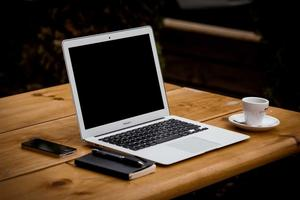

In [4]:
# Create a multi-modal message with random image and text.
pil_image = PIL.Image.open(io.BytesIO(requests.get("https://picsum.photos/300/200").content))
img = autogen_core.Image(pil_image)
multi_modal_message = msg.MultiModalMessage(content=["Can you describe the content of this image?", img], source="user")
img


### Streaming Messages
- Streaming each message can be done using the `run_stream()` method and use Console to print the messages as they appear to the console as shown in the below cell.

In [5]:
async def assistant_run_stream() -> None:
    # Option 1: read each message from the stream (as shown in the previous example).
    # async for message in agent.run_stream(task="Find information on AutoGen"):
    #     print(message)

    # Option 2: use Console to print all messages as they appear.
    await ui.Console(
        autogen_agentchat.run_stream(task="Find information on AutoGen"),
        output_stats=True,  # Enable stats printing.
    )


# Use asyncio.run(assistant_run_stream()) when running in a script.
await assistant_run_stream()

---------- TextMessage (user) ----------
Find information on AutoGen
---------- ToolCallRequestEvent (assistant) ----------
[FunctionCall(id='call_rIzbMn9XwP95lQwcckVSCHaC', arguments='{"query":"AutoGen"}', name='web_search')]
[Prompt tokens: 61, Completion tokens: 15]
---------- ToolCallExecutionEvent (assistant) ----------
[FunctionExecutionResult(content='AutoGen is a programming framework for building multi-agent applications.', name='web_search', call_id='call_rIzbMn9XwP95lQwcckVSCHaC', is_error=False)]
---------- ToolCallSummaryMessage (assistant) ----------
AutoGen is a programming framework for building multi-agent applications.
---------- Summary ----------
Number of messages: 4
Finish reason: None
Total prompt tokens: 61
Total completion tokens: 15
Duration: 0.53 seconds


### Function Tool
- The web_search_func tool is an example of a function tool. The schema is automatically generated.
- The cell below shows its working

In [6]:
# Define a tool using a Python function.
async def web_search_func(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."


# This step is automatically performed inside the AssistantAgent if the tool is a Python function.
web_search_function_tool = tools.FunctionTool(web_search_func, description="Find information on the web")
# The schema is provided to the model during AssistantAgent's on_messages call.
web_search_function_tool.schema

{'name': 'web_search_func',
 'description': 'Find information on the web',
 'parameters': {'type': 'object',
  'properties': {'query': {'description': 'query',
    'title': 'Query',
    'type': 'string'}},
  'required': ['query'],
  'additionalProperties': False},
 'strict': False}

### Parallel Tool Calls
Some models can call multiple tools simultaneously. By default, `AssistantAgent` executes parallel tool calls if the model client produces them.

> **Caution:** Disable parallel tool calls when tools have side effects or when consistent agent behavior is required. This is configured at the model client level.

**Important:**  
- `AgentTool` and `TeamTool` **must not** run in parallel due to internal state conflicts.  
- For `OpenAIChatCompletionClient` and `AzureOpenAIChatCompletionClient`, set `parallel_tool_calls=False` to disable parallel execution.

In [7]:
model_client_no_parallel_tool_call = openai.OpenAIChatCompletionClient(
    model="gpt-4o",
    parallel_tool_calls=False,  # type: ignore
    api_key=OPENAI_API_KEY, 

)
agent_no_parallel_tool_call = agent.AssistantAgent(
    name="assistant",
    model_client=model_client_no_parallel_tool_call,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

### Tool Iterations
- One model call followed by one tool call or parallel tool calls is a single tool iteration. By default, the AssistantAgent will execute at most one iteration.

In [8]:
agent_loop = agent.AssistantAgent(
    name="assistant_loop",
    model_client=model_client_no_parallel_tool_call,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
    max_tool_iterations=10,  # At most 10 iterations of tool calls before stopping the loop.
)

### Streaming Tokens
- You can stream the tokens generated by the model client by setting model_client_stream=True. This will cause the agent to yield ModelClientStreamingChunkEvent messages in run_stream() as shown in the below cell.
- You can see the streaming chunks in the output above. The chunks are generated by the model client and are yielded by the agent as they are received. The final response, the concatenation of all the chunks, is yielded right after the last chunk in the output in the cell below

In [9]:

streaming_assistant = agent.AssistantAgent(
    name="assistant",
    model_client=openai_model_client,
    system_message="You are a helpful assistant.",
    model_client_stream=True,  # Enable streaming tokens.
)

# Use an async function and asyncio.run() in a script.
async for message in streaming_assistant.run_stream(task="Name two cities in South America"):  # type: ignore
    print(message)

id='72daea9f-784b-410d-acc1-3038f5f3fe0a' source='user' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 19, 15, 59, 50, 946900, tzinfo=datetime.timezone.utc) content='Name two cities in South America' type='TextMessage'
id='d53c9c73-ea17-454e-a1e5-7360cf99b98d' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 19, 15, 59, 51, 311612, tzinfo=datetime.timezone.utc) content='Two' full_message_id='a763e01a-672c-4307-8c0b-abc71a2db52d' type='ModelClientStreamingChunkEvent'
id='2018825d-3c81-410d-8d5d-314161e87a6f' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 19, 15, 59, 51, 311844, tzinfo=datetime.timezone.utc) content=' cities' full_message_id='a763e01a-672c-4307-8c0b-abc71a2db52d' type='ModelClientStreamingChunkEvent'
id='89154b4f-1b71-483c-a465-0ce32466ba92' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 2, 19, 15, 59, 51, 312410, tzinfo=datetime.timezon

## Messages
There are primarily 2 types of messages in autogen:
- Agent-Agent Messages
- Agent's Internal Events

### The Below cell shows the working of Agent to Agent communication

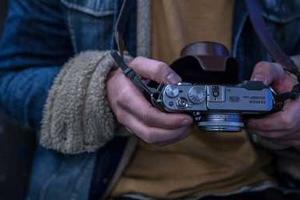


--- Message from User ---
['Look at this camera feed and discuss it.', <autogen_core._image.Image object at 0x704f2874b530>]

--- Message from Vision_Specialist ---
The image shows a person holding a camera or possibly a digital camcorder. The individual is wearing a denim jacket with a tan or beige fuzzy cuff, suggesting a casual or outdoorsy setting. Their hands are gripping the device, which appears to be ready for use, possibly for taking photos or shooting video. The background is somewhat blurred but indicates they might be outdoors or in a setting where casual clothing is appropriate. Overall, the focus is on the person's hands and the camera, indicating an interest in photography or videography.

--- Message from Reviewer ---
This camera feed seems to capture someone in the act of holding a digital camera or camcorder, possibly preparing to take a picture or record a video. The person's attire suggests a casual, perhaps outdoor environment. The focus on their hands and the cam

In [10]:
# 1. Setup the Model Client (using existing openai_model_client from previous step)

# 2. Define Agent A: The Vision Specialist
vision_agent = agent.AssistantAgent(
    name="Vision_Specialist",
    model_client=openai_model_client,
    system_message="Describe the image provided in detail."
)

# 3. Define Agent B: The Reviewer
reviewer_agent = agent.AssistantAgent(
    name="Reviewer",
    model_client=openai_model_client,
    system_message="Based on the description provided, suggest one creative use for this item."
)

# 4. Create the Team (This enables true Agent-to-Agent communication)
agent_team = teams.RoundRobinGroupChat(
    [vision_agent, reviewer_agent],
    max_turns=2
)

# 5. Prepare the MultiModalMessage from your local file
pil_image = PIL.Image.open("camera.png")
img = autogen_core.Image(pil_image)
IPython.display.display(pil_image)

input_message = msg.MultiModalMessage(
    content=["Look at this camera feed and discuss it.", img],
    source="User"
)

# 6. Run the Team
# The team will pass the MultiModalMessage from the User to Agent A, 
# then Agent A's response to Agent B automatically.
async for message in agent_team.run_stream(task=input_message):
    # TaskResult objects don't have 'source', so we check if 'source' exists
    if hasattr(message, "source"):
        print(f"\n--- Message from {message.source} ---")
        print(message.content)
    else:
        # This handles the final TaskResult object
        print("\n--- Task Complete ---")
        # Optional: print(message.stop_reason)

### Agent's Internal Events
- In the below example, the agent does not show reasoning because the question is a simple factual lookup, and the model directly produces the answer without generating visible step-by-step reasoning.

In [11]:
async def internal_events():
    # 1. Setup the client using the 'openai' alias

    # 2. Setup the agent using the 'agent' alias
    # model_client_stream=True is required to see the internal 'Thinking' events
    solo_agent = agent.AssistantAgent(
        name="Solo_Assistant",
        model_client=openai_model_client,
        system_message="You are a helpful assistant.",
        model_client_stream=True 
    )

    print("--- Execution Started ---\n")

    # 3. Process the stream using the 'msg' and 'base' aliases
    async for event in solo_agent.run_stream(task="What is the capital of France?"):
        
        # Internal "Live" Streaming (Individual tokens as they arrive)
        if isinstance(event, msg.ModelClientStreamingChunkEvent):
            if event.content:
                print(event.content, end="", flush=True)

        # Final Messages (Completed response blocks)
        # We check specific types to avoid the generic ChatMessage TypeError
        elif isinstance(event, (msg.TextMessage, msg.MultiModalMessage, msg.StopMessage)):
            # Filter out the 'user' prompt to keep the output clean
            if event.source != "user":
                print(f"\n\n[FINAL MESSAGE from {event.source}]:")
                print(event.content)

        # Final Summary using the 'base' alias
        elif isinstance(event, base.TaskResult):
            print(f"\n\n--- Task Finished | Reason: {event.stop_reason} ---")

# Run the block
await internal_events()

--- Execution Started ---

The capital of France is Paris.

[FINAL MESSAGE from Solo_Assistant]:
The capital of France is Paris.


--- Task Finished | Reason: None ---


## Teams
AgentChat supports several team presets:
- RoundRobinGroupChat: A team that runs a group chat with participants taking turns in a round-robin fashion (covered on this page). 
- SelectorGroupChat: A team that selects the next speaker using a ChatCompletion model after each message. 
- MagenticOneGroupChat: A generalist multi-agent system for solving open-ended web and file-based tasks across a variety of domains. 
- Swarm: A team that uses HandoffMessage to signal transitions between agents.

The demonstration will primarily highlight `SelectorGroupChat`, as it is the key element in the `autogen.example.ipynb example`.

In [12]:
# Analyst system message (no TERMINATE here)
analyst = agent.AssistantAgent(
    name="Analyst",
    model_client=openai_model_client,
    system_message="""
You are a Senior Quantitative Analyst.
Answer clearly and concisely.
"""
)

# Reviewer system message
reviewer = agent.AssistantAgent(
    name="Reviewer",
    model_client=openai_model_client,
    system_message="""
You are a peer reviewer.
Comment on the Analyst's output briefly.
"""
)

# Team termination condition
termination_condition = conditions.TextMentionTermination("TERMINATE")  # you can instead use a timeout or max_turns
team = teams.SelectorGroupChat(
    [analyst, reviewer],
    model_client=openai_model_client,
    termination_condition=termination_condition, 
    max_turns=6
)

### Observing a Team
- Similar to the agent’s `on_messages_stream()` method, you can stream the team’s messages while it is running by calling the `run_stream()` method. This method returns a generator that yields messages produced by the agents in the team as they are generated, with the final item being the TaskResult object.



In [13]:
# Task prompt
task_prompt = "Summarize the hypothetical company 'ExampleCorp' in 2 sentences. Provide one key insight."

# Run
async for message in team.run_stream(task=task_prompt):
    if hasattr(message, "source") and isinstance(message.content, str):
        print(f"{message.source}: {message.content.strip()}\n")
    elif hasattr(message, "stop_reason"):
        print(f"🏁 Mission Complete: {message.stop_reason}\n")


user: Summarize the hypothetical company 'ExampleCorp' in 2 sentences. Provide one key insight.

Analyst: ExampleCorp is a technology-focused company specializing in innovative software solutions for enterprise clients. Its key insight is that strategic investments in cloud-based platforms have significantly driven its recent revenue growth and market expansion.

Reviewer: The summary effectively highlights ExampleCorp’s core business and recent growth driver. However, incorporating additional details about the company's market position or competitive advantages could provide a more comprehensive overview.

Analyst: Thank you for the feedback. Here's an improved version:

ExampleCorp is a leading technology company providing innovative software solutions for enterprise clients, with a strong market position driven by its advanced cloud platform offerings. Its key insight is that strategic investments in cloud-based infrastructure have been crucial in accelerating revenue growth and enh

## Human in the Loop

There are two main ways to interact with the team from your application:
- During a team’s run – execution of `run()` or `run_stream()`, provide feedback through a UserProxyAgent.
- Once the run terminates, provide feedback through input to the next call to `run()` or `run_stream()`.

### Providing Feedback During a Run

The **UserProxyAgent** is a built-in agent that acts as a human-in-the-loop bridge, allowing users to provide direct feedback to an AI team.

#### Integration

Create an instance of `UserProxyAgent` and include it in your team (e.g., `RoundRobinGroupChat` or `SelectorGroupChat`) before execution.

#### Execution Logic

- **Round Robin:** The agent is called in the specific order it was passed to the team.  
- **Selector:** A selector prompt or function determines exactly when the user needs to intervene.

#### Control Flow

When called, the team transfers control to the user and **blocks execution**. Once feedback is provided, control returns to the team to resume the task.

> **Important:**  
> Because this is a blocking operation, it is best suited for short interactions requiring immediate attention such as approving a plan or providing a missing prompt to avoid leaving the team in an unstable, unresumable state.

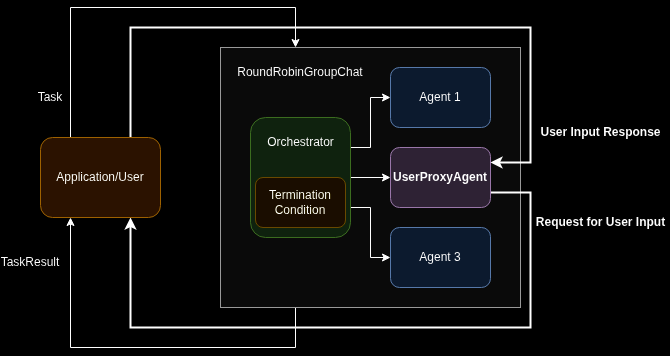

There are two ways to implement this approach:
- Set the maximum number of turns so that the team always stops after the specified number of turns.
- Use termination conditions such as `TextMentionTermination` and `HandoffTermination` to allow the team to decide when to stop and give control back, given the team’s internal state.

Here is an example of how to use `max_turns` in a `RoundRobinGroupChat` for a poetry generation task with a maximum of 1 turn:



In [14]:
# Create the agents.
model_client = openai.OpenAIChatCompletionClient(model="gpt-4o-mini",     
                                          api_key=OPENAI_API_KEY, 
)
assistant = agent.AssistantAgent("assistant", model_client=model_client)

# Create the team setting a maximum number of turns to 1.

task = "Write a 4-line poem about the ocean."
while True:
    # Run the conversation and stream to the console.
    stream = team.run_stream(task=task)
    # Use asyncio.run(...) when running in a script.
    await ui.Console(stream)
    # Get the user response.
    task = input("Enter your feedback (type 'exit' to leave): ")
    if task.lower().strip() == "exit":
        break
await model_client.close()

---------- TextMessage (user) ----------
Write a 4-line poem about the ocean.
---------- TextMessage (assistant) ----------
Beneath the skies of endless blue,  
The waves dance wild, both fierce and true.  
Whispers of secrets, ancient and wise,  
In the depths where the mystery lies.  


Enter your feedback (type 'exit' to leave):  exit


### Using termination condition 
- `HandoffTermination` is a specialized termination condition that stops a team's execution specifically when an agent sends a HandoffMessage. Unlike general limits (like `max_turns`), this allows an AssistantAgent to dynamically signal when it lacks the relevant tools or information to continue.

- When an agent reaches a dead end or requires external input, it triggers a handoff, transferring control back to the user. This effectively pauses the automated workflow at a logical junction, allowing for manual intervention or the provision of missing data before the task proceeds further.

In [15]:
# Create an OpenAI model client.
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o",
    api_key=OPENAI_API_KEY, # Optional if you have an OPENAI_API_KEY env variable set.
)

# Create a lazy assistant agent that always hands off to the user.
lazy_agent = agent.AssistantAgent(
    "lazy_assistant",
    model_client=model_client,
    handoffs=[base.Handoff(target="user", message="Transfer to user.")],
    system_message="If you cannot complete the task, transfer to user. Otherwise, when finished, respond with 'TERMINATE'.",
)

# Define a termination condition that checks for handoff messages.
handoff_termination = conditions.HandoffTermination(target="user")
# Define a termination condition that checks for a specific text mention.
text_termination = conditions.TextMentionTermination("TERMINATE")

# Create a single-agent team with the lazy assistant and both termination conditions.
lazy_agent_team = teams.RoundRobinGroupChat([lazy_agent], termination_condition=handoff_termination | text_termination)

# Run the team and stream to the console.
task = "What is the weather in New York?"
await ui.Console(lazy_agent_team.run_stream(task=task), output_stats=True)


---------- TextMessage (user) ----------
What is the weather in New York?
---------- ToolCallRequestEvent (lazy_assistant) ----------
[FunctionCall(id='call_bPusa5X5rwn6urVRXhFLbPJ3', arguments='{}', name='transfer_to_user')]
[Prompt tokens: 69, Completion tokens: 11]
---------- ToolCallExecutionEvent (lazy_assistant) ----------
[FunctionExecutionResult(content='Transfer to user.', name='transfer_to_user', call_id='call_bPusa5X5rwn6urVRXhFLbPJ3', is_error=False)]
---------- HandoffMessage (lazy_assistant) ----------
Transfer to user.
---------- Summary ----------
Number of messages: 4
Finish reason: Handoff to user from lazy_assistant detected.
Total prompt tokens: 69
Total completion tokens: 11
Duration: 0.69 seconds


TaskResult(messages=[TextMessage(id='ad38f495-b09e-4037-8cba-5ab65f58c78c', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 0, 14, 891051, tzinfo=datetime.timezone.utc), content='What is the weather in New York?', type='TextMessage'), ToolCallRequestEvent(id='1f63fccf-ad4b-4fbc-bb7e-36cd0f6efef1', source='lazy_assistant', models_usage=RequestUsage(prompt_tokens=69, completion_tokens=11), metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 0, 15, 574209, tzinfo=datetime.timezone.utc), content=[FunctionCall(id='call_bPusa5X5rwn6urVRXhFLbPJ3', arguments='{}', name='transfer_to_user')], type='ToolCallRequestEvent'), ToolCallExecutionEvent(id='08b1ba4c-46aa-4ed2-bef4-7361c73436bf', source='lazy_assistant', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 0, 15, 575873, tzinfo=datetime.timezone.utc), content=[FunctionExecutionResult(content='Transfer to user.', name='transfer_to_user', call_id='call_bPusa5X5rwn6

You can see the team stopped due to the handoff message was detected. Let’s continue the team by providing the information the agent needs.

In [17]:
await ui.Console(lazy_agent_team.run_stream(task="The weather in New York is sunny."))


---------- TextMessage (user) ----------
The weather in New York is sunny.
---------- TextMessage (lazy_assistant) ----------
TERMINATE


TaskResult(messages=[TextMessage(id='6afc0b40-8131-4edd-afc0-2591fc56f8d1', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 2, 50, 135829, tzinfo=datetime.timezone.utc), content='The weather in New York is sunny.', type='TextMessage'), TextMessage(id='b677540d-beed-446c-9e6c-799e8765912c', source='lazy_assistant', models_usage=RequestUsage(prompt_tokens=106, completion_tokens=4), metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 2, 50, 561344, tzinfo=datetime.timezone.utc), content='TERMINATE', type='TextMessage')], stop_reason="Text 'TERMINATE' mentioned")

You can see the team continued after the user provided the information.



## Termination

AgentChat uses the `TerminationCondition` base class to manage when a team's execution should stop.
- Mechanism: It evaluates recent agent events or messages, returning a StopMessage to terminate the run or `None` to continue.
- State Management: Conditions are stateful and reset automatically after each `run()` or `run_stream()`. If reused manually, you must call `reset()`.
- Flexibility: You can combine multiple conditions using AND (`&`) and OR (`|`) operators to create complex exit logic.

To show the working of the termination conditions. The cell below consists of two agents: 
- a primary agent responsible for text generation
- a critic agent that reviews and provides feedback on the generated text.

In [20]:
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o",
    temperature=1,
    api_key=OPENAI_API_KEY,
)

# Create the primary agent.
primary_agent = agent.AssistantAgent(
    "primary",
    model_client=model_client,
    system_message="You are a helpful AI assistant.",
)

# Create the critic agent.
critic_agent = agent.AssistantAgent(
    "critic",
    model_client=model_client,
    system_message="Provide constructive feedback for every message. Respond with 'APPROVE' to when your feedbacks are addressed.",
)

Termination conditions automatically reset after each run or run_stream call, allowing the team to resume its conversation from where it left off.

In [22]:
max_msg_termination = conditions.MaxMessageTermination(max_messages=3)
round_robin_team = teams.RoundRobinGroupChat([primary_agent, critic_agent], termination_condition=max_msg_termination)

# Use asyncio.run(...) if you are running this script as a standalone script.
await ui.Console(round_robin_team.run_stream(task="Write a unique, Haiku about the weather in Paris"))

---------- TextMessage (user) ----------
Write a unique, Haiku about the weather in Paris
---------- TextMessage (primary) ----------
Gentle rain whispers,  
Eiffel shrouded in soft mist—  
Paris breathes in gray.
---------- TextMessage (critic) ----------
This Haiku beautifully captures the essence of Parisian weather. The imagery of "gentle rain" and the "Eiffel shrouded in soft mist" effectively paints a vivid picture of a typical rainy day in Paris. Furthermore, the phrase "Paris breathes in gray" poetically reflects the city's atmospheric mood during such weather, embracing the aesthetics of overcast days.

Good job! Keep up the creative work! 

APPROVE


TaskResult(messages=[TextMessage(id='3e5f0e61-06fc-47b9-8736-92e558628166', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 22, 0, 235860, tzinfo=datetime.timezone.utc), content='Write a unique, Haiku about the weather in Paris', type='TextMessage'), TextMessage(id='33ab8dfe-51b4-4afe-abf0-ebf4fcdd7636', source='primary', models_usage=RequestUsage(prompt_tokens=30, completion_tokens=22), metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 22, 1, 446781, tzinfo=datetime.timezone.utc), content='Gentle rain whispers,  \nEiffel shrouded in soft mist—  \nParis breathes in gray.', type='TextMessage'), TextMessage(id='2051041d-4b07-4361-bd0c-bad9c5231c44', source='critic', models_usage=RequestUsage(prompt_tokens=73, completion_tokens=88), metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 22, 3, 734656, tzinfo=datetime.timezone.utc), content='This Haiku beautifully captures the essence of Parisian weather. The imagery of "gentle rain

The conversation stopped after reaching the maximum message limit. Since the primary agent didn’t get to respond to the feedback, let’s continue the conversation.



In [23]:
await ui.Console(round_robin_team.run_stream())


---------- TextMessage (primary) ----------
Thank you for the kind words! I'm glad you enjoyed the Haiku. If you have any other requests or need assistance with anything else, feel free to let me know!
---------- TextMessage (critic) ----------
You're welcome! I'm here to help, so if you have any other writing projects or need assistance, just ask. Keep creating and expressing your unique perspective! 

APPROVE
---------- TextMessage (primary) ----------
Thank you for your encouragement! I'll be here whenever you need assistance or inspiration. Don't hesitate to reach out with any projects or ideas you want to explore. Happy writing!


TaskResult(messages=[TextMessage(id='264ba1e1-dfcb-49cf-ace8-c70a33160c01', source='primary', models_usage=RequestUsage(prompt_tokens=150, completion_tokens=35), metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 22, 35, 135433, tzinfo=datetime.timezone.utc), content="Thank you for the kind words! I'm glad you enjoyed the Haiku. If you have any other requests or need assistance with anything else, feel free to let me know!", type='TextMessage'), TextMessage(id='aead228a-08bc-4a87-9ccb-fd3249385ac1', source='critic', models_usage=RequestUsage(prompt_tokens=206, completion_tokens=35), metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 22, 36, 775566, tzinfo=datetime.timezone.utc), content="You're welcome! I'm here to help, so if you have any other writing projects or need assistance, just ask. Keep creating and expressing your unique perspective! \n\nAPPROVE", type='TextMessage'), TextMessage(id='2cb1c46b-4844-40af-840d-16ed93c2baaf', source='primary', models_usage=Reques

## Managing State

We can get the state of an agent by calling `save_state()` method on an AssistantAgent.



In [28]:
model_client = openai.OpenAIChatCompletionClient(model="gpt-4o-2024-08-06", 
                                         api_key=OPENAI_API_KEY,)

assistant_agent = agent.AssistantAgent(
    name="assistant_agent",
    system_message="You are a helpful assistant",
    model_client=model_client,
)

# Use asyncio.run(...) when running in a script.
response = await assistant_agent.on_messages(
    [msg.TextMessage(content="Write a 3 line poem on lake tangayika", source="user")], autogen_core.CancellationToken()
)
print(response.chat_message)
await model_client.close()

id='26aa494d-9659-46a5-aa09-d6d16bb691da' source='assistant_agent' models_usage=RequestUsage(prompt_tokens=28, completion_tokens=24) metadata={} created_at=datetime.datetime(2026, 2, 19, 16, 30, 8, 674714, tzinfo=datetime.timezone.utc) content="In Tanganyika's depths so wide,  \nSecrets of the ages hide.  \nWhere waters whisper, dreams abide.  " type='TextMessage'


The state can be saved by using the command below

In [29]:
agent_state = await assistant_agent.save_state()
print(agent_state)

{'type': 'AssistantAgentState', 'version': '1.0.0', 'llm_context': {'messages': [{'content': 'Write a 3 line poem on lake tangayika', 'source': 'user', 'type': 'UserMessage'}, {'content': "In Tanganyika's depths so wide,  \nSecrets of the ages hide.  \nWhere waters whisper, dreams abide.  ", 'thought': None, 'source': 'assistant_agent', 'type': 'AssistantMessage'}]}}


## Saving and Loading Teams

In [37]:
model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o-2024-08-06",
    api_key=OPENAI_API_KEY,
)

# Define a team.
assistant_agent = agent.AssistantAgent(
    name="assistant_agent",
    system_message="You are a helpful assistant",
    model_client=model_client,
)
agent_team = teams.RoundRobinGroupChat([assistant_agent], termination_condition=conditions.MaxMessageTermination(max_messages=2))

# Run the team and stream messages to the console.
stream = agent_team.run_stream(task="Write a beautiful poem 3-line about lake tangayika")

# Use asyncio.run(...) when running in a script.
await ui.Console(stream)

# Save the state of the agent team.
team_state = await agent_team.save_state()


---------- TextMessage (user) ----------
Write a beautiful poem 3-line about lake tangayika
---------- TextMessage (assistant_agent) ----------
In Tanganyika's depths, whispers of time prevail,  
Emerald waters cradle ancient tales anew,  
Under starlit skies, dreams in ripples sail.  


If we reset the team (simulating instantiation of the team), and ask the question What was the last line of the poem you wrote?, we see that the team is unable to accomplish this as there is no reference to the previous run.

In [39]:
await agent_team.reset()
stream = agent_team.run_stream(task="What was the last line of the poem you wrote?")
await ui.Console(stream)

---------- TextMessage (user) ----------
What was the last line of the poem you wrote?
---------- TextMessage (assistant_agent) ----------
I don't have the capability to recall past interactions or specific content that I created in previous chats. However, I would be happy to help you create a new poem or provide you with a closing line for a poem if you'd like!


TaskResult(messages=[TextMessage(id='31ff7c2a-7772-4ec7-b7bd-3e024dc59347', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 37, 14, 101465, tzinfo=datetime.timezone.utc), content='What was the last line of the poem you wrote?', type='TextMessage'), TextMessage(id='f7a7745d-c4da-4d8c-9e10-4e82583ca929', source='assistant_agent', models_usage=RequestUsage(prompt_tokens=28, completion_tokens=46), metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 37, 15, 313308, tzinfo=datetime.timezone.utc), content="I don't have the capability to recall past interactions or specific content that I created in previous chats. However, I would be happy to help you create a new poem or provide you with a closing line for a poem if you'd like!", type='TextMessage')], stop_reason='Maximum number of messages 2 reached, current message count: 2')

Next, we load the state of the team and ask the same question. We see that the team is able to accurately return the last line of the poem it wrote.



In [41]:
print(team_state)

# Load team state.
await agent_team.load_state(team_state)
stream = agent_team.run_stream(task="What was the last line of the poem you wrote?")
await ui.Console(stream)

{'type': 'TeamState', 'version': '1.0.0', 'agent_states': {'assistant_agent': {'type': 'ChatAgentContainerState', 'version': '1.0.0', 'agent_state': {'type': 'AssistantAgentState', 'version': '1.0.0', 'llm_context': {'messages': [{'content': 'Write a beautiful poem 3-line about lake tangayika', 'source': 'user', 'type': 'UserMessage'}, {'content': "In Tanganyika's depths, whispers of time prevail,  \nEmerald waters cradle ancient tales anew,  \nUnder starlit skies, dreams in ripples sail.  ", 'thought': None, 'source': 'assistant_agent', 'type': 'AssistantMessage'}]}}, 'message_buffer': []}, 'RoundRobinGroupChatManager': {'type': 'RoundRobinManagerState', 'version': '1.0.0', 'message_thread': [{'id': 'a179d29b-979a-4fef-aaea-6a7e7e8c2263', 'source': 'user', 'models_usage': None, 'metadata': {}, 'created_at': '2026-02-19T16:36:10.560105Z', 'content': 'Write a beautiful poem 3-line about lake tangayika', 'type': 'TextMessage'}, {'id': '0bf9519b-578d-41c6-bbb1-d878f6a3a2e8', 'source': 'as

TaskResult(messages=[TextMessage(id='6568aaac-ca72-4b69-addc-c69e21c08991', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 38, 14, 494521, tzinfo=datetime.timezone.utc), content='What was the last line of the poem you wrote?', type='TextMessage'), TextMessage(id='b9835d8d-f8f0-4ef9-9d16-652a357432c9', source='assistant_agent', models_usage=RequestUsage(prompt_tokens=83, completion_tokens=24), metadata={}, created_at=datetime.datetime(2026, 2, 19, 16, 38, 15, 228075, tzinfo=datetime.timezone.utc), content='The last line of the poem I wrote is:  \n"Under starlit skies, dreams in ripples sail."', type='TextMessage')], stop_reason='Maximum number of messages 2 reached, current message count: 2')